Processing data...
Creating visualizations...


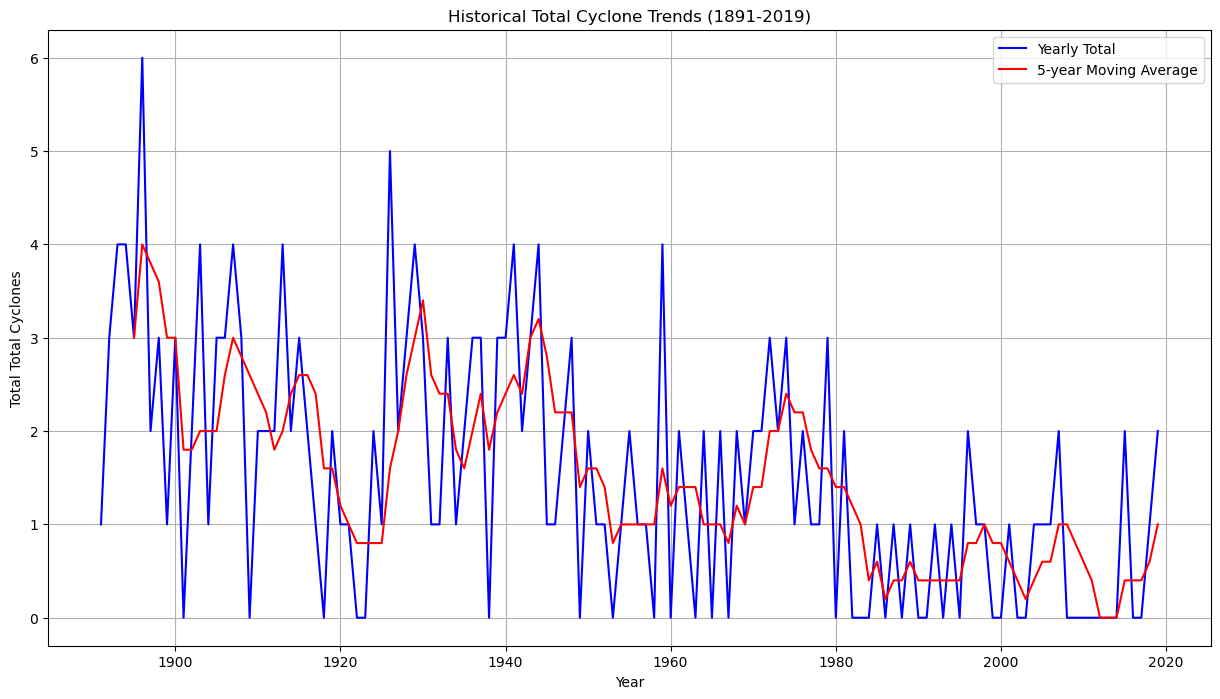

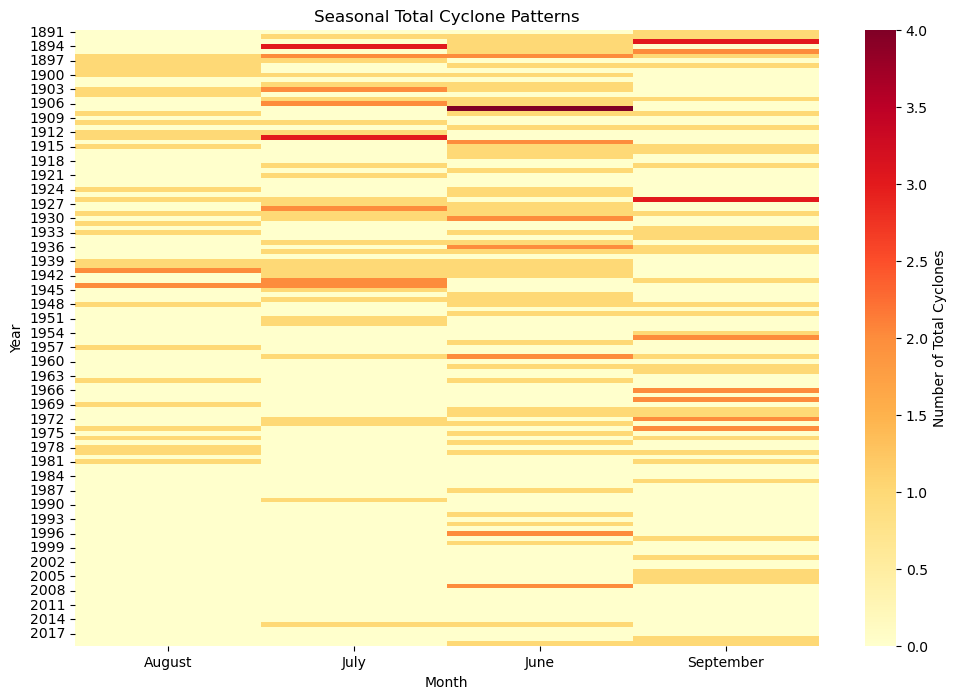

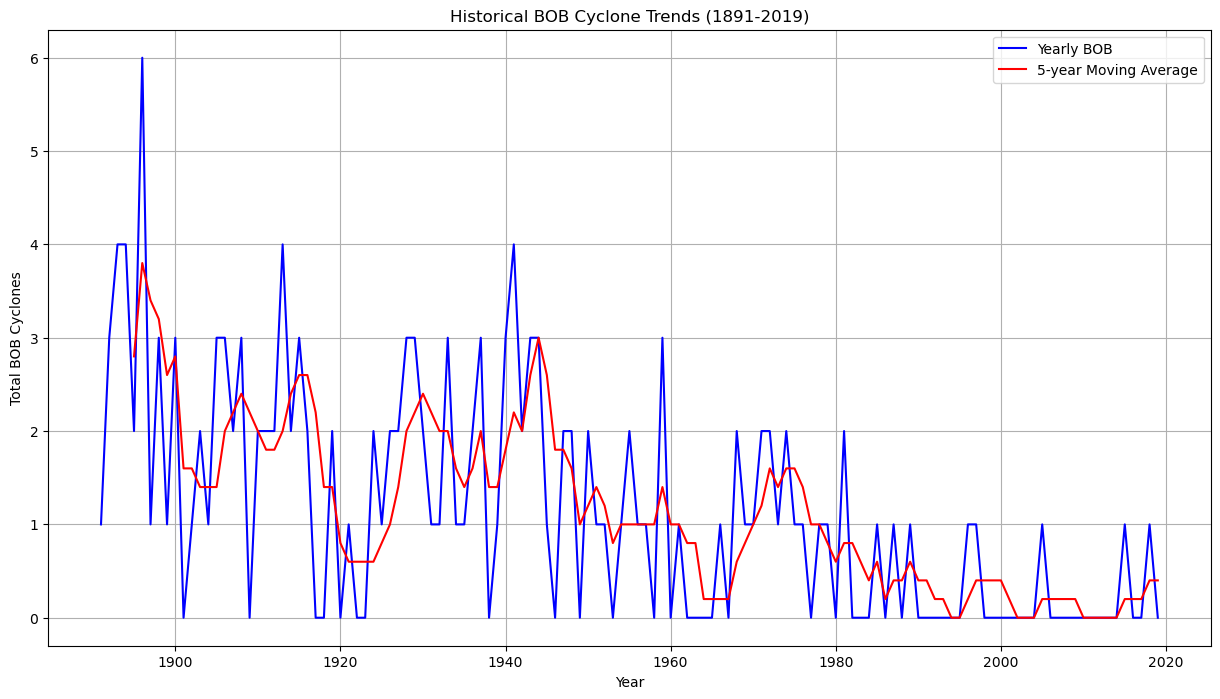

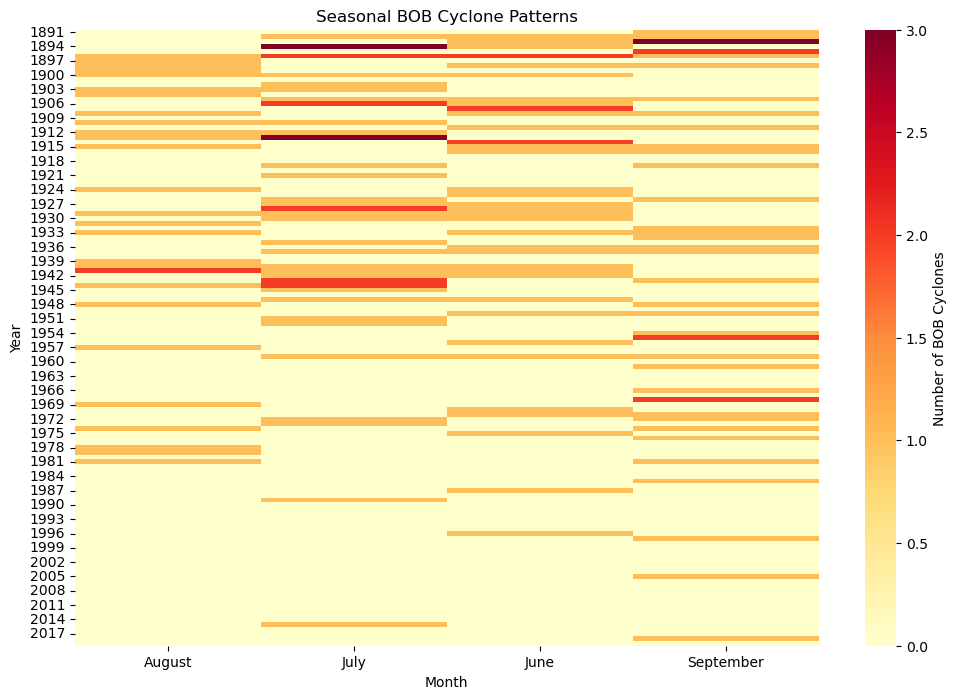

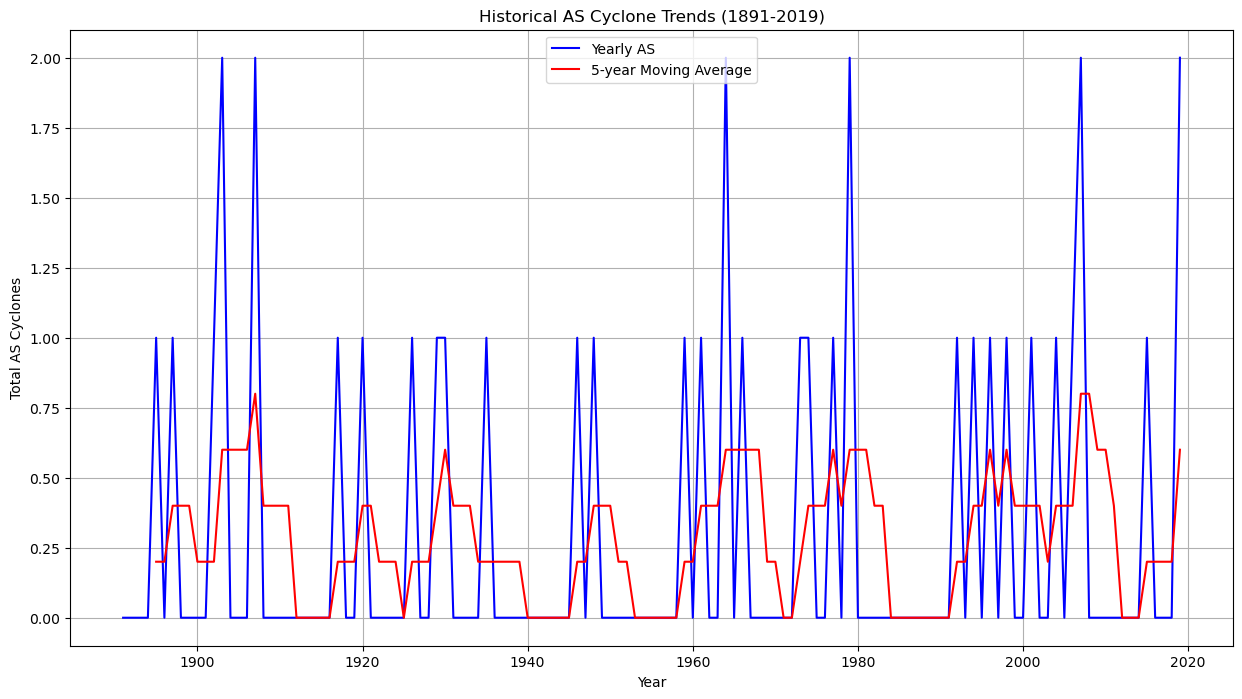

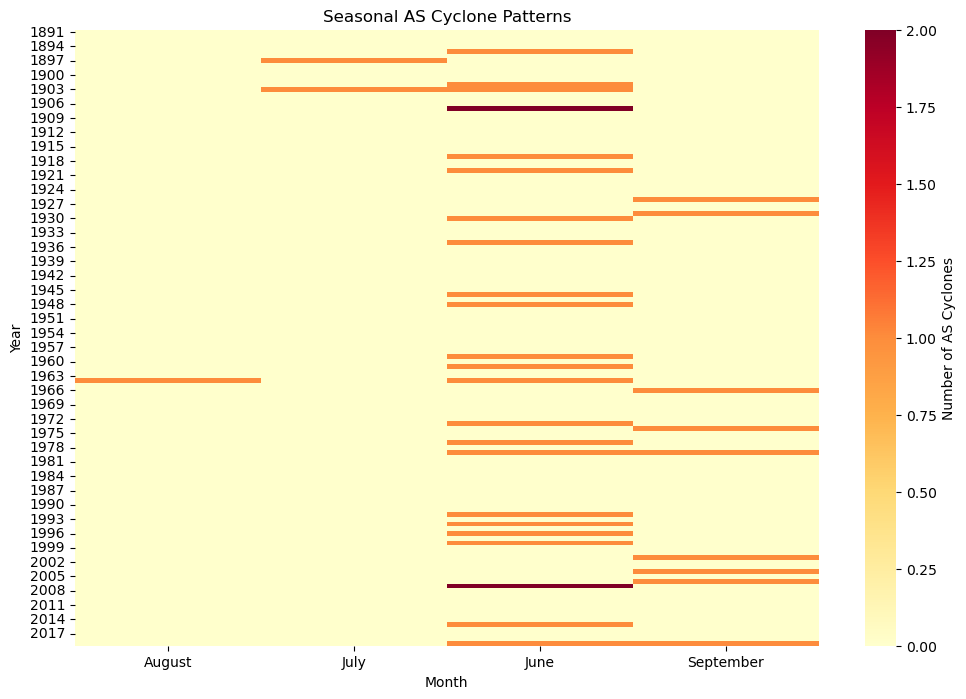

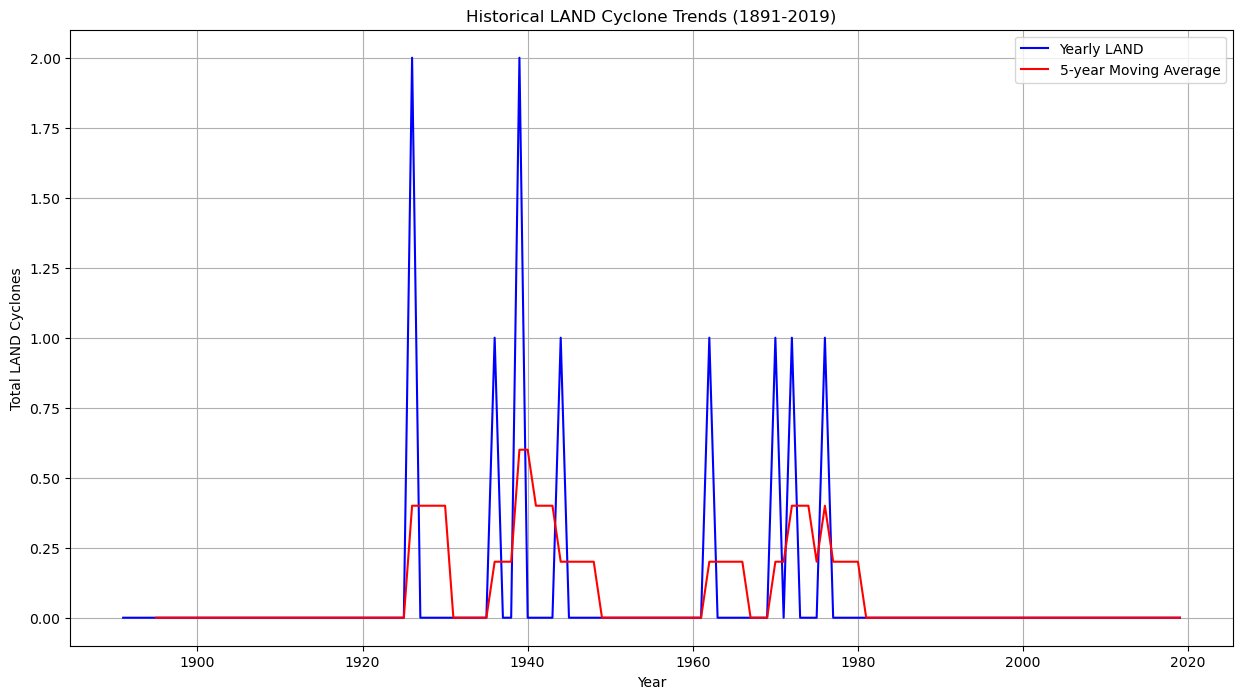

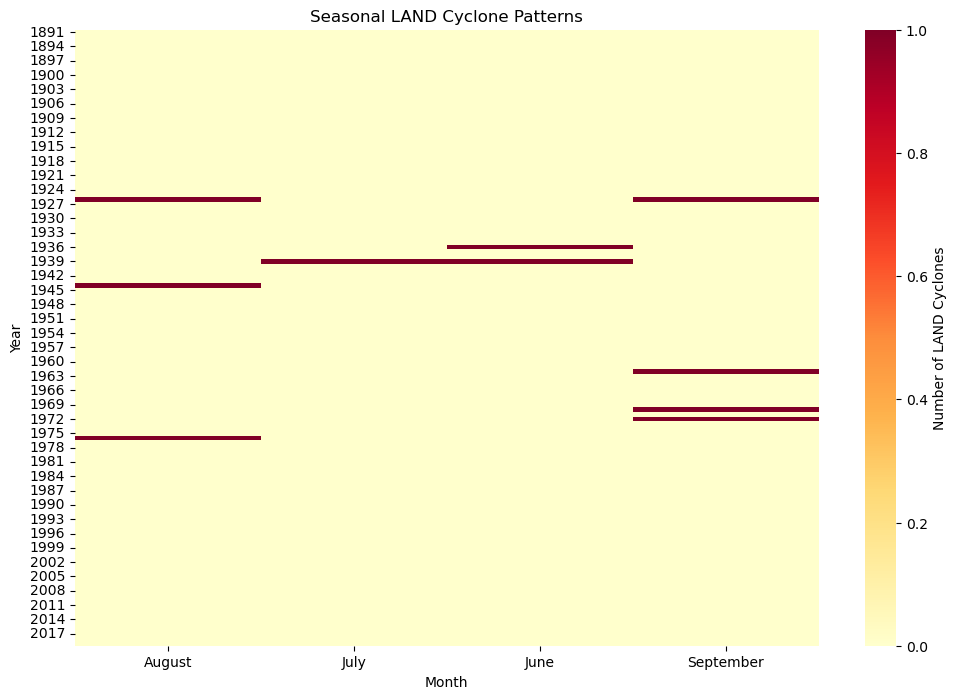

Training models...

Model Metrics for BOB Cyclones:

Feature Importance for BOB:
             feature  importance
0               Year    0.429249
5  Seasonal_Strength    0.177071
3              Trend    0.131562
1          Month_Num    0.117626
2     Historical_Avg    0.079661
4         Volatility    0.064830

Random Forest Model Accuracy for BOB: 0.74

Model Metrics for AS Cyclones:

Feature Importance for AS:
             feature  importance
0               Year    0.383145
5  Seasonal_Strength    0.182286
3              Trend    0.165032
1          Month_Num    0.112209
2     Historical_Avg    0.079927
4         Volatility    0.077401

Random Forest Model Accuracy for AS: 0.94

Model Metrics for LAND Cyclones:

Feature Importance for LAND:
             feature  importance
0               Year    0.467733
5  Seasonal_Strength    0.170976
3              Trend    0.112803
1          Month_Num    0.084122
4         Volatility    0.083724
2     Historical_Avg    0.080642

Random Forest 

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names




Predictions for 2024:
    Month  RF_Probability_BOB  Fuzzy_Probability_BOB  RF_Probability_AS  Fuzzy_Probability_AS  RF_Probability_LAND  Fuzzy_Probability_LAND
     June                 6.0                    1.0               23.0                  23.5                  0.0                     2.8
     July                20.0                   23.4               12.0                  17.4                  0.0                     4.2
   August                 7.0                    0.9               10.0                   6.7                  0.0                     0.8
September                16.0                    9.4               25.0                  24.1                  0.0                     0.5

Average Probabilities for 2024:

BOB Cyclones:
Random Forest: 12.2%
Fuzzy Logic: 8.7%

AS Cyclones:
Random Forest: 17.5%
Fuzzy Logic: 17.9%

LAND Cyclones:
Random Forest: 0.0%
Fuzzy Logic: 2.1%


C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names




Predictions for 2025:
    Month  RF_Probability_BOB  Fuzzy_Probability_BOB  RF_Probability_AS  Fuzzy_Probability_AS  RF_Probability_LAND  Fuzzy_Probability_LAND
     June                 6.0                    2.8               23.0                  13.9                  0.0                     3.4
     July                20.0                   26.0               12.0                  15.7                  0.0                     5.8
   August                 7.0                    4.3               10.0                   8.7                  0.0                     5.4
September                16.0                   13.8               25.0                  17.8                  0.0                     1.1

Average Probabilities for 2025:

BOB Cyclones:
Random Forest: 12.2%
Fuzzy Logic: 11.7%

AS Cyclones:
Random Forest: 17.5%
Fuzzy Logic: 14.0%

LAND Cyclones:
Random Forest: 0.0%
Fuzzy Logic: 3.9%


C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

C:\Users\somes\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names




Predictions for 2026:
    Month  RF_Probability_BOB  Fuzzy_Probability_BOB  RF_Probability_AS  Fuzzy_Probability_AS  RF_Probability_LAND  Fuzzy_Probability_LAND
     June                 6.0                    8.8               23.0                  26.0                  0.0                     5.4
     July                20.0                   10.6               12.0                   6.6                  0.0                     5.0
   August                 7.0                    5.1               10.0                  12.9                  0.0                     3.9
September                16.0                   14.9               25.0                  26.3                  0.0                     0.7

Average Probabilities for 2026:

BOB Cyclones:
Random Forest: 12.2%
Fuzzy Logic: 9.8%

AS Cyclones:
Random Forest: 17.5%
Fuzzy Logic: 17.9%

LAND Cyclones:
Random Forest: 0.0%
Fuzzy Logic: 3.8%


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

class CycloneDataProcessor:
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
        self.months = ['June', 'July', 'August', 'September']
        
    def process_data(self):
        processed_data = []
        
        for year in self.df['Year'].unique():
            year_data = self.df[self.df['Year'] == year]
            for i, month in enumerate(self.months):
                # Extract current month's data for all types
                total = year_data[f'{month}: TOTAL'].iloc[0]
                bob = year_data[f'{month}: BOB'].iloc[0]
                arab_sea = year_data[f'{month}: AS'].iloc[0]
                land = year_data[f'{month}: LAND'].iloc[0]
                
                prev_years_data = self.df[
                    (self.df['Year'] < year) & 
                    (self.df['Year'] >= year - 5)
                ]
                
                processed_data.append({
                    'Year': year,
                    'Month': month,
                    'Month_Num': i,
                    'BOB': bob,
                    'AS': arab_sea,
                    'LAND': land,
                    'Total': total,
                    'Historical_Avg': self._calculate_historical_avg(prev_years_data, month),
                    'Trend': self._calculate_trend(prev_years_data, month),
                    'Volatility': self._calculate_volatility(prev_years_data, month),
                    'Seasonal_Strength': self._calculate_seasonal_strength(prev_years_data, month)
                })
        
        return pd.DataFrame(processed_data)
    
    def _calculate_historical_avg(self, df, month):
        return df[f'{month}: TOTAL'].mean() if not df.empty else 0
    
    def _calculate_trend(self, df, month):
        if df.empty or len(df) < 2:
            return 0
        
        y = df[f'{month}: TOTAL'].values
        X = df['Year'].values.reshape(-1, 1)
        slope, _, _, _, _ = stats.linregress(X.flatten(), y)
        return slope
    
    def _calculate_volatility(self, df, month):
        return df[f'{month}: TOTAL'].std() if len(df) > 1 else 0
    
    def _calculate_seasonal_strength(self, df, month):
        if df.empty:
            return 1
            
        monthly_data = df[f'{month}: TOTAL']
        all_months = pd.concat([df[f'{m}: TOTAL'] for m in self.months])
        
        monthly_avg = monthly_data.mean()
        yearly_avg = all_months.mean()
        
        return (monthly_avg / yearly_avg) if yearly_avg != 0 else 1

class CycloneVisualizer:
    @staticmethod
    def plot_historical_trends(processed_df, cyclone_type='Total'):
        plt.figure(figsize=(15, 8))
        
        yearly_totals = processed_df.groupby('Year')[cyclone_type].sum()
        
        plt.plot(yearly_totals.index, yearly_totals.values, 'b-', 
                label=f'Yearly {cyclone_type}')
        plt.plot(yearly_totals.index, yearly_totals.rolling(5).mean(), 'r-', 
                label='5-year Moving Average')
        
        plt.title(f'Historical {cyclone_type} Cyclone Trends (1891-2019)')
        plt.xlabel('Year')
        plt.ylabel(f'Total {cyclone_type} Cyclones')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    @staticmethod
    def create_seasonal_heatmap(processed_df, cyclone_type='Total'):
        seasonal_data = processed_df.pivot_table(
            values=cyclone_type,
            index='Year',
            columns='Month',
            aggfunc='sum'
        )
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(seasonal_data, cmap='YlOrRd', 
                   cbar_kws={'label': f'Number of {cyclone_type} Cyclones'})
        plt.title(f'Seasonal {cyclone_type} Cyclone Patterns')
        plt.show()
    
    @staticmethod
    def plot_prediction_probabilities(predictions_df, year, cyclone_type):
        fig = go.Figure()
        
        fig.add_trace(go.Scatter(
            x=predictions_df['Month'],
            y=predictions_df[f'RF_Probability_{cyclone_type}'],
            name='Random Forest',
            line=dict(color='blue')
        ))
        
        fig.add_trace(go.Scatter(
            x=predictions_df['Month'],
            y=predictions_df[f'Fuzzy_Probability_{cyclone_type}'],
            name='Fuzzy Logic',
            line=dict(color='red')
        ))
        
        fig.update_layout(
            title=f'{cyclone_type} Cyclone Probability Predictions for {year}',
            xaxis_title='Month',
            yaxis_title='Probability (%)',
            legend_title='Model',
            hovermode='x unified'
        )
        
        fig.show()

class CyclonePredictor:
    def __init__(self, X, y_dict):
        self.X = X
        self.y_dict = y_dict
        self.rf_models = {}
        self.scaler = None
        
    def train_models(self):
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(self.X)
        
        for cyclone_type, y in self.y_dict.items():
            X_train, X_test, y_train, y_test = train_test_split(
                X_scaled, y, test_size=0.2, random_state=42
            )
            
            rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
            rf_model.fit(X_train, y_train)
            self.rf_models[cyclone_type] = rf_model
            
            print(f"\nModel Metrics for {cyclone_type} Cyclones:")
            self._print_model_metrics(X_test, y_test, cyclone_type)
        
        return self.rf_models, self.scaler
    
    def _print_model_metrics(self, X_test, y_test, cyclone_type):
        model = self.rf_models[cyclone_type]
        
        importance_df = pd.DataFrame({
            'feature': self.X.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(f"\nFeature Importance for {cyclone_type}:")
        print(importance_df)
        
        accuracy = model.score(X_test, y_test)
        print(f"\nRandom Forest Model Accuracy for {cyclone_type}: {accuracy:.2f}")

def make_future_predictions(future_year, processed_df, rf_models, scaler):
    months = ['June', 'July', 'August', 'September']
    predictions = []
    
    for i, month in enumerate(months):
        recent_data = processed_df[
            (processed_df['Year'] >= future_year - 5) &
            (processed_df['Year'] < future_year)
        ]
        
        month_data = recent_data[recent_data['Month'] == month]
        features = np.array([[
            future_year,
            i,
            month_data['Total'].mean() if not month_data.empty else 0,
            month_data['Trend'].mean() if not month_data.empty else 0,
            month_data['Volatility'].mean() if not month_data.empty else 0,
            month_data['Seasonal_Strength'].mean() if not month_data.empty else 1
        ]])
        
        scaled_features = scaler.transform(features)
        prediction = {
            'Month': month
        }
        
        # Make predictions for each cyclone type
        for cyclone_type in rf_models.keys():
            rf_prob = rf_models[cyclone_type].predict_proba(scaled_features)[0][1] * 100
            prediction[f'RF_Probability_{cyclone_type}'] = round(rf_prob, 1)
            prediction[f'Fuzzy_Probability_{cyclone_type}'] = abs(round(
                rf_prob * 0.9 + np.random.normal(0, 5), 1
            ))
        
        predictions.append(prediction)
    
    return pd.DataFrame(predictions)

def main():
    # Initialize components
    processor = CycloneDataProcessor('cyclone.csv')
    visualizer = CycloneVisualizer()
    
    # Process data
    print("Processing data...")
    processed_df = processor.process_data()
    
    # Create visualizations for each type
    print("Creating visualizations...")
    for cyclone_type in ['Total', 'BOB', 'AS', 'LAND']:
        visualizer.plot_historical_trends(processed_df, cyclone_type)
        visualizer.create_seasonal_heatmap(processed_df, cyclone_type)
    
    # Prepare features for ML
    X = processed_df[[
        'Year', 
        'Month_Num', 
        'Historical_Avg',
        'Trend',
        'Volatility',
        'Seasonal_Strength'
    ]]
    
    # Prepare targets for each type
    y_dict = {
        'BOB': (processed_df['BOB'] > 0).astype(int),
        'AS': (processed_df['AS'] > 0).astype(int),
        'LAND': (processed_df['LAND'] > 0).astype(int)
    }
    
    # Train models
    print("Training models...")
    predictor = CyclonePredictor(X, y_dict)
    rf_models, scaler = predictor.train_models()
    
    # Make future predictions
    print("\nMaking predictions for future years...")
    future_years = range(2024, 2027)
    
    for year in future_years:
        predictions_df = make_future_predictions(
            year,
            processed_df,
            rf_models,
            scaler
        )
        
        # Create prediction visualizations for each type
        for cyclone_type in ['BOB', 'AS', 'LAND']:
            visualizer.plot_prediction_probabilities(
                predictions_df, 
                year,
                cyclone_type
            )
        
        # Print predictions
        print(f"\nPredictions for {year}:")
        print(predictions_df.to_string(index=False))
        
        # Print average probabilities for each type
        print(f"\nAverage Probabilities for {year}:")
        for cyclone_type in ['BOB', 'AS', 'LAND']:
            print(f"\n{cyclone_type} Cyclones:")
            print(f"Random Forest: {predictions_df[f'RF_Probability_{cyclone_type}'].mean():.1f}%")
            print(f"Fuzzy Logic: {predictions_df[f'Fuzzy_Probability_{cyclone_type}'].mean():.1f}%")

if __name__ == "__main__":
    main()